In [1]:
import os, json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)
from tqdm import tqdm

DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MAX_LENGTH = 512
BATCH_SIZE = 32
print(f"Device: {DEVICE}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cpu


In [6]:
class CodeDefectDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        code  = str(self.data.loc[idx, 'clean_code'])
        label = int(self.data.loc[idx, 'target'])
        enc   = self.tokenizer(code, max_length=self.max_length,
                               padding='max_length', truncation=True,
                               return_tensors='pt')
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long)
        }


class CodeReviewModel(nn.Module):
    def __init__(self, model_name, num_labels=2, dropout=0.3):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden_size     = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_size, 256),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


# Load tokenizer and test data
tokenizer = AutoTokenizer.from_pretrained('tokenizer/')
test_df   = pd.read_csv('data/test_clean.csv')

test_dataset = CodeDefectDataset(test_df, tokenizer, MAX_LENGTH)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Load best model from the actual saved location
checkpoint_candidates = [
    '/Users/jin/Desktop/projects/Intelligent-Code-Review-Assistant-Using-Deep-Learning/code-review-ai/.gitignore/checkpoints/best_model.pt',
    '/Users/jin/Desktop/projects/Intelligent-Code-Review-Assistant-Using-Deep-Learning/code-review-ai/checkpoints/best_model.pt',
    '/Users/jin/Desktop/projects/Intelligent-Code-Review-Assistant-Using-Deep-Learning/code-review-ai/notebooks/checkpoints/best_model.pt',
]
checkpoint_path = next((path for path in checkpoint_candidates if os.path.exists(path)), None)

if checkpoint_path is None:
    raise FileNotFoundError(
        'Could not find best_model.pt. Tried: ' + ', '.join(checkpoint_candidates)
    )

model = CodeReviewModel('microsoft/codebert-base').to(DEVICE)
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()
print(f"✅ Model loaded from {checkpoint_path}")
print(f"Test samples: {len(test_dataset)}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 64318.91it/s]



✅ Model loaded from /Users/jin/Desktop/projects/Intelligent-Code-Review-Assistant-Using-Deep-Learning/code-review-ai/.gitignore/checkpoints/best_model.pt
Test samples: 2732


In [8]:
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Running inference'):
        input_ids      = batch['input_ids'].to(DEVICE)
        attention_mask = batch['attention_mask'].to(DEVICE)
        labels         = batch['label'].to(DEVICE)

        logits = model(input_ids, attention_mask)
        probs  = F.softmax(logits, dim=1)[:, 1]   # probability of class 1 (defective)
        preds  = logits.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print(f"Inference complete. Total predictions: {len(all_preds)}")

Running inference: 100%|██████████| 86/86 [06:06<00:00,  4.26s/it]

Inference complete. Total predictions: 2732


In [9]:
accuracy  = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='binary')
recall    = recall_score(all_labels, all_preds, average='binary')
f1        = f1_score(all_labels, all_preds, average='binary')

print("=" * 45)
print("       EVALUATION RESULTS (Test Set)")
print("=" * 45)
print(f"  Accuracy:  {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print("=" * 45)
print()
print("--- Full Classification Report ---")
print(classification_report(all_labels, all_preds,
                             target_names=['Clean (0)', 'Defective (1)']))

       EVALUATION RESULTS (Test Set)
  Accuracy:  0.5622  (56.22%)
  Precision: 0.5651
  Recall:    0.2040
  F1-Score:  0.2998

--- Full Classification Report ---
               precision    recall  f1-score   support

    Clean (0)       0.56      0.87      0.68      1477
Defective (1)       0.57      0.20      0.30      1255

     accuracy                           0.56      2732
    macro avg       0.56      0.54      0.49      2732
 weighted avg       0.56      0.56      0.51      2732



In [10]:
class CodeDefectDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data       = dataframe.reset_index(drop=True)
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        code  = str(self.data.loc[idx, 'clean_code'])
        label = int(self.data.loc[idx, 'target'])
        enc   = self.tokenizer(code, max_length=self.max_length,
                               padding='max_length', truncation=True,
                               return_tensors='pt')
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'label'          : torch.tensor(label, dtype=torch.long)
        }


class CodeReviewModel(nn.Module):
    def __init__(self, model_name, num_labels=2, dropout=0.3):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden_size     = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout), nn.Linear(hidden_size, 256),
            nn.ReLU(), nn.Dropout(dropout), nn.Linear(256, num_labels)
        )

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return self.classifier(out.last_hidden_state[:, 0, :])


# Load tokenizer and test data
tokenizer = AutoTokenizer.from_pretrained('tokenizer/')
test_df   = pd.read_csv('data/test_clean.csv')

test_dataset = CodeDefectDataset(test_df, tokenizer, MAX_LENGTH)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Load best model from the actual saved location
checkpoint_candidates = [
    '/Users/jin/Desktop/projects/Intelligent-Code-Review-Assistant-Using-Deep-Learning/code-review-ai/.gitignore/checkpoints/best_model.pt',
    '/Users/jin/Desktop/projects/Intelligent-Code-Review-Assistant-Using-Deep-Learning/code-review-ai/checkpoints/best_model.pt',
    '/Users/jin/Desktop/projects/Intelligent-Code-Review-Assistant-Using-Deep-Learning/code-review-ai/notebooks/checkpoints/best_model.pt',
]
checkpoint_path = next((path for path in checkpoint_candidates if os.path.exists(path)), None)

if checkpoint_path is None:
    raise FileNotFoundError(
        'Could not find best_model.pt. Tried: ' + ', '.join(checkpoint_candidates)
    )

model = CodeReviewModel('microsoft/codebert-base').to(DEVICE)
model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
model.eval()
print(f"✅ Model loaded from {checkpoint_path}")
print(f"Test samples: {len(test_dataset)}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 53210.92it/s]



✅ Model loaded from /Users/jin/Desktop/projects/Intelligent-Code-Review-Assistant-Using-Deep-Learning/code-review-ai/.gitignore/checkpoints/best_model.pt
Test samples: 2732


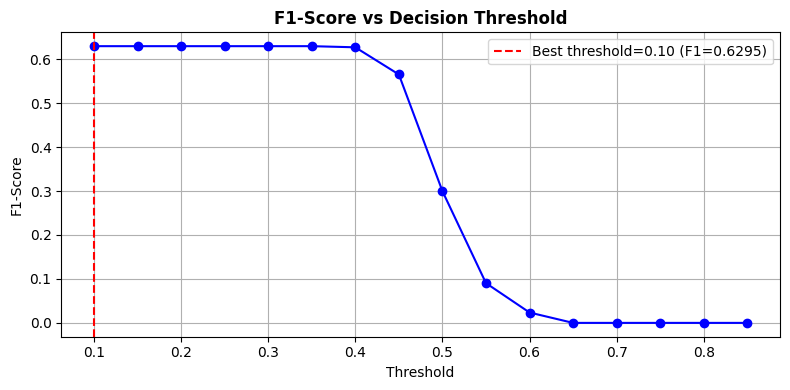

Default threshold (0.5): F1 = 0.2998
Best threshold (0.10): F1 = 0.6295


In [11]:
# Find threshold that maximizes F1
thresholds_range = np.arange(0.1, 0.9, 0.05)
f1_scores = []
for t in thresholds_range:
    preds_t = (all_probs >= t).astype(int)
    f1_scores.append(f1_score(all_labels, preds_t, average='binary', zero_division=0))

best_threshold = thresholds_range[np.argmax(f1_scores)]
best_f1        = max(f1_scores)

plt.figure(figsize=(8, 4))
plt.plot(thresholds_range, f1_scores, 'b-o')
plt.axvline(x=best_threshold, color='red', linestyle='--',
            label=f'Best threshold={best_threshold:.2f} (F1={best_f1:.4f})')
plt.title('F1-Score vs Decision Threshold', fontsize=12, fontweight='bold')
plt.xlabel('Threshold'); plt.ylabel('F1-Score')
plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig('checkpoints/threshold_analysis.png', dpi=150)
plt.show()

print(f"Default threshold (0.5): F1 = {f1:.4f}")
print(f"Best threshold ({best_threshold:.2f}): F1 = {best_f1:.4f}")

In [14]:
cm = confusion_matrix(all_labels, all_preds)

# Compute ROC AUC safely
if len(np.unique(all_labels)) > 1:
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    roc_auc = auc(fpr, tpr)
else:
    roc_auc = float('nan')

report = {
    'accuracy':        float(accuracy),
    'precision':       float(precision),
    'recall':          float(recall),
    'f1_score':        float(f1),
    'auc_roc':         float(roc_auc) if not np.isnan(roc_auc) else None,
    'best_threshold':  float(best_threshold),
    'best_f1':         float(best_f1),
    'confusion_matrix': cm.tolist()
}

os.makedirs('checkpoints', exist_ok=True)
with open('checkpoints/eval_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("✅ Evaluation report saved to checkpoints/eval_report.json")
print(json.dumps(report, indent=2))

✅ Evaluation report saved to checkpoints/eval_report.json
{
  "accuracy": 0.5622254758418741,
  "precision": 0.565121412803532,
  "recall": 0.20398406374501993,
  "f1_score": 0.2997658079625293,
  "auc_roc": 0.552381132207797,
  "best_threshold": 0.1,
  "best_f1": 0.6295460245798846,
  "confusion_matrix": [
    [
      1280,
      197
    ],
    [
      999,
      256
    ]
  ]
}
